In [3]:
# Name : Mounika Nemalikanti
# ID   : 2025DA04009
# Assignment 2 - Customer Churn Prediction Using Machine Learning
# Source data - https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

*Step 2: Load Dataset*

In [6]:
df = pd.read_csv("Telco-Customer-Churn_Dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# -----------------------------
# Dataset Exploration
# -----------------------------

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Summary:")
print(df.describe())

Dataset Shape: (7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn

**Step 3: Data Preprocessing**

Check Missing Values

In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


*Remove Customer ID*

In [9]:
df.drop("customerID", axis=1, inplace=True)

In [22]:
#Convert TotalCharges to Numeric#
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [10]:
#Encode Target Variable#
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

In [11]:
#Encode Categorical Columns#
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

Churn Count and Percentage

In [13]:
# -----------------------------
# Churn Count and Percentage
# -----------------------------

churn_yes = df[df["Churn"] == 1]
churn_no = df[df["Churn"] == 0]

print("Total Customers =", len(df))
print("Customers who Churned =", len(churn_yes))
print("Churn Percentage =", len(churn_yes) / len(df) * 100, "%")

print("Customers who did not Churn =", len(churn_no))
print("Non-Churn Percentage =", len(churn_no) / len(df) * 100, "%")

Total Customers = 7043
Customers who Churned = 1869
Churn Percentage = 26.536987079369588 %
Customers who did not Churn = 5174
Non-Churn Percentage = 73.4630129206304 %


**Step 4 - Data Visualization**

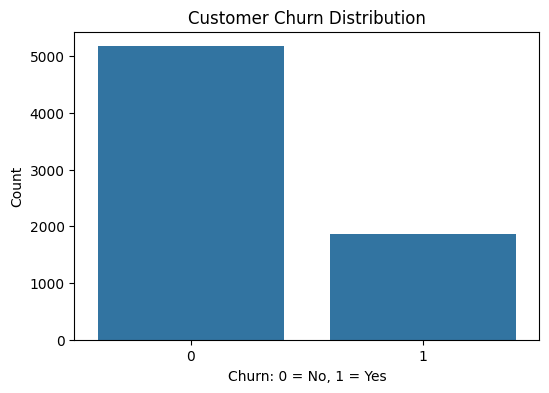

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Churn Distribution
# -----------------------------

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

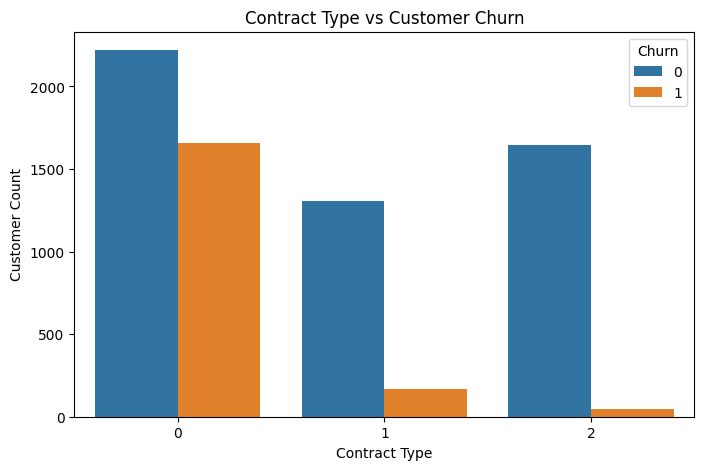

In [16]:
# -----------------------------
# Contract Type vs Churn
# -----------------------------

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()

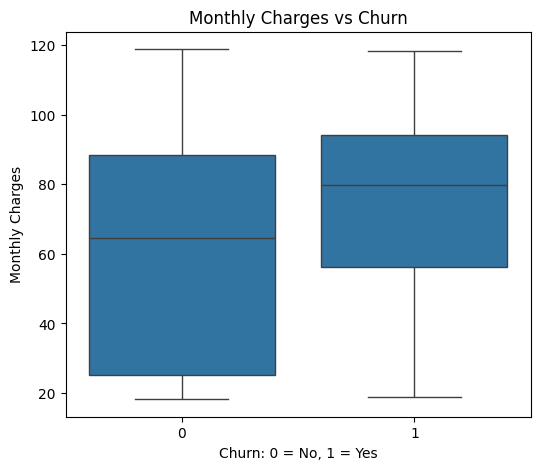

In [17]:
# -----------------------------
# Monthly Charges vs Churn
# -----------------------------

plt.figure(figsize=(6,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn: 0 = No, 1 = Yes")
plt.ylabel("Monthly Charges")
plt.show()

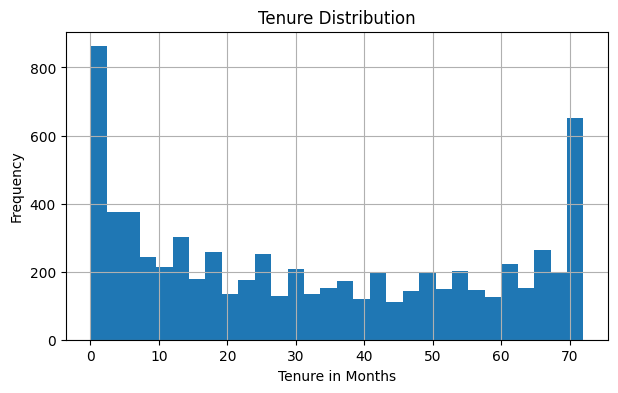

In [18]:

# Tenure Distribution


plt.figure(figsize=(7,4))
df["tenure"].hist(bins=30)
plt.title("Tenure Distribution")
plt.xlabel("Tenure in Months")
plt.ylabel("Frequency")
plt.show()

**Feature and Target Selection**

In [30]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

Step 5: Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=45,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4930, 19)
Testing Shape: (2113, 19)


Step 6: Feature Scaling

In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 7: Evaluation Function

In [50]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    return [accuracy, auc, precision, recall, f1, mcc]

Step 8: Logistic Regression

In [53]:
lr = LogisticRegression()

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Logistic Regression Done")

Logistic Regression Done


In [55]:
dt = DecisionTreeClassifier(random_state=42)

dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Decision Tree Done")

Decision Tree Done


Step 10: KNN Classifier

In [58]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_results = evaluate_model(
    knn,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("KNN Done")

KNN Done


Step 11: Naive Bayes Classifier

In [61]:
nb = GaussianNB()

nb_results = evaluate_model(
    nb,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print("Naive Bayes Done")

Naive Bayes Done


Step 12: Random Forest Classifier

In [64]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Random Forest Done")

Random Forest Done


**Confusion Matrix for Each Model**

In [60]:
from sklearn.metrics import confusion_matrix

# -----------------------------
# Function to Plot Confusion Matrix
# -----------------------------

def plot_confusion_matrix(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    cm = confusion_matrix(y_test_data, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(model_name + " - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

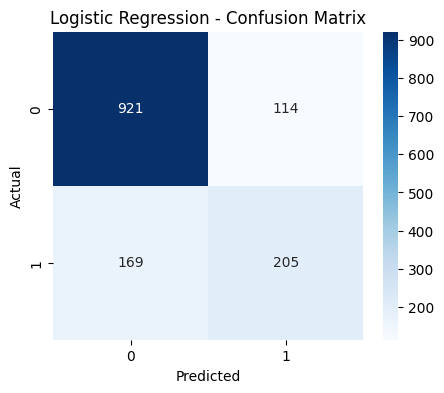

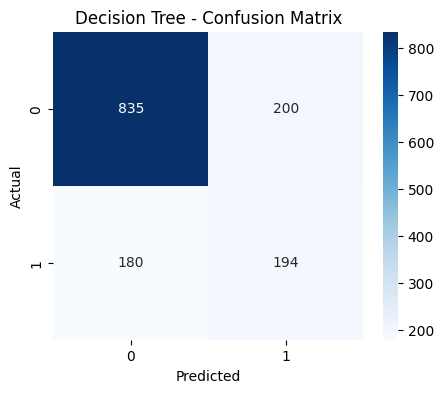

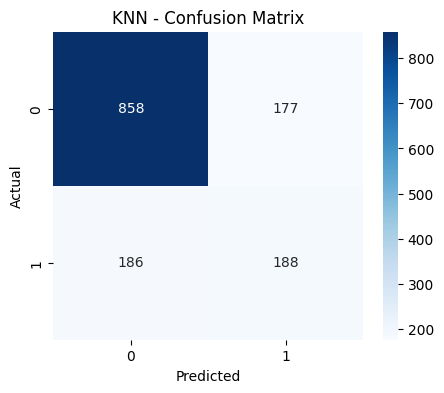

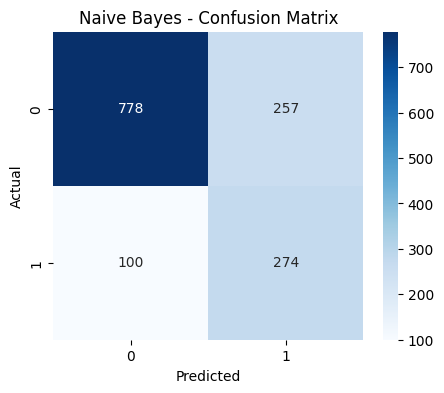

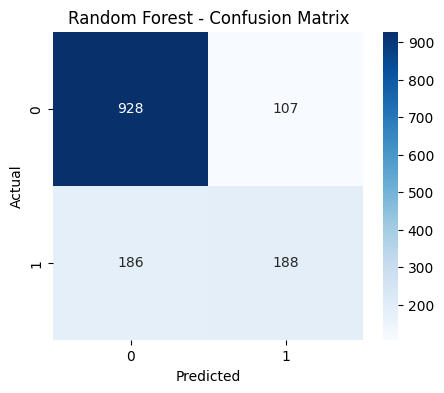

In [62]:
plot_confusion_matrix(lr, X_test_scaled, y_test, "Logistic Regression")
plot_confusion_matrix(dt, X_test, y_test, "Decision Tree")
plot_confusion_matrix(knn, X_test_scaled, y_test, "KNN")
plot_confusion_matrix(nb, X_test_scaled, y_test, "Naive Bayes")
plot_confusion_matrix(rf, X_test, y_test, "Random Forest")

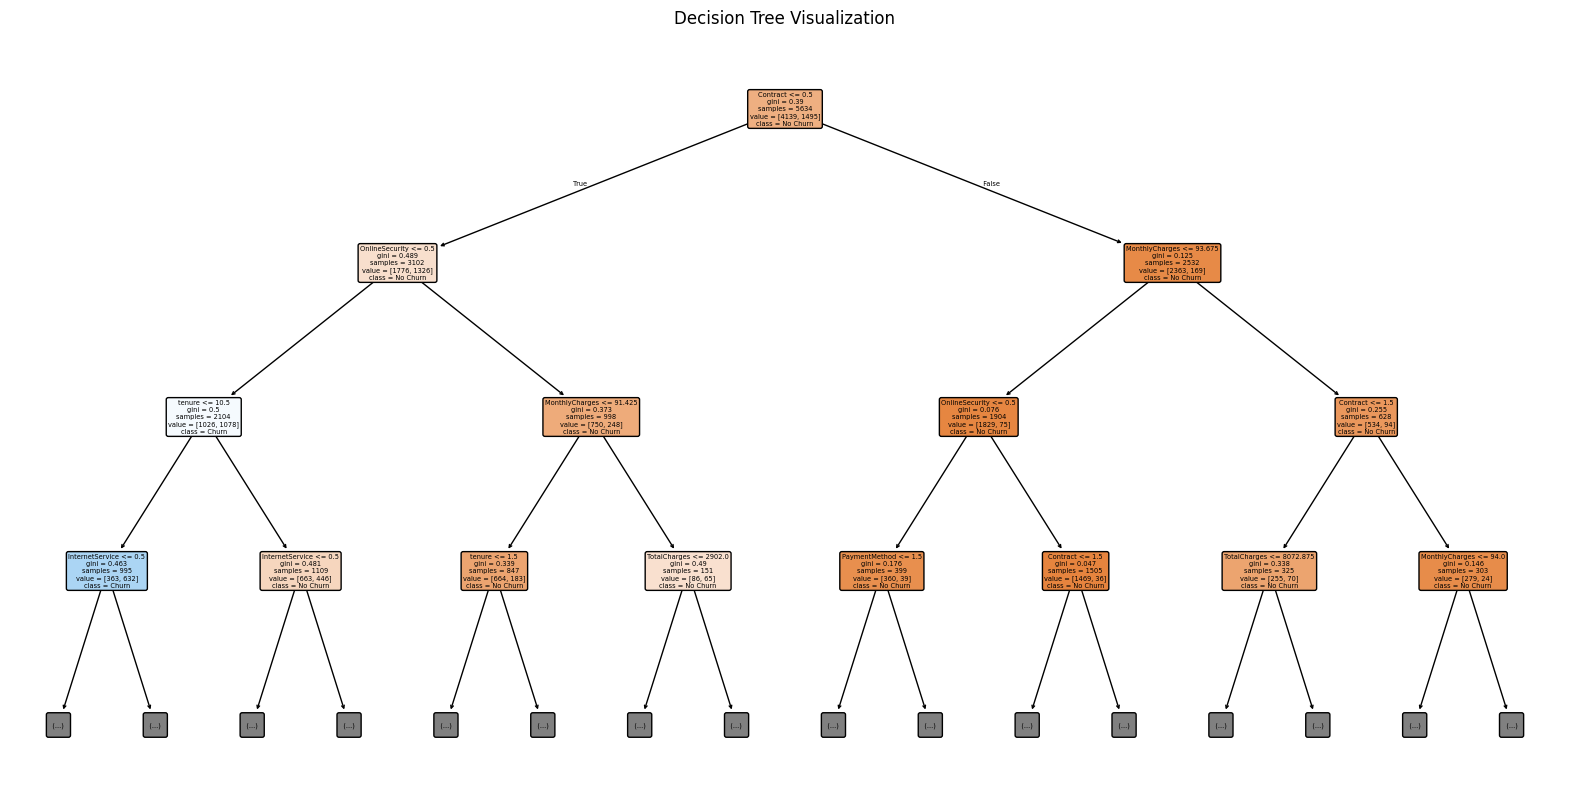

In [64]:
from sklearn import tree

# -----------------------------
# Decision Tree Visualization
# -----------------------------

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

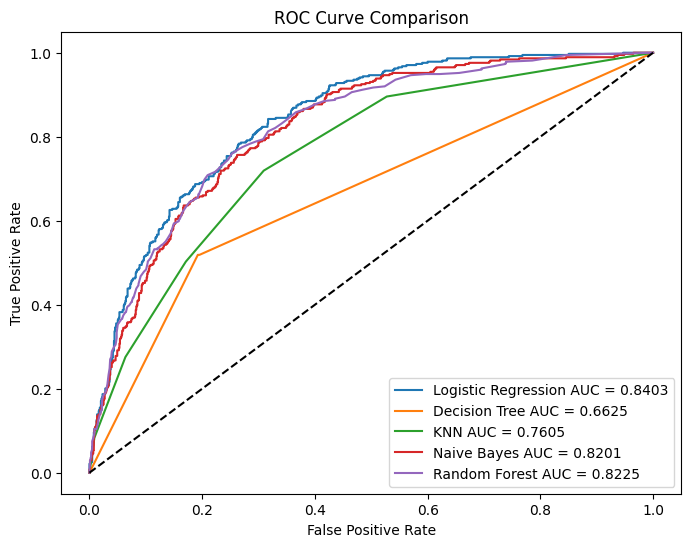

In [104]:
from sklearn.metrics import roc_curve, auc

# -----------------------------
# ROC Curve Comparison
# -----------------------------

plt.figure(figsize=(8,6))

models_for_roc = {
    "Logistic Regression": (lr, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "KNN": (knn, X_test_scaled),
    "Naive Bayes": (nb, X_test_scaled),
    "Random Forest": (rf, X_test)
}

for model_name, model_data in models_for_roc.items():
    model, X_data = model_data

    y_prob = model.predict_proba(X_data)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=model_name + " AUC = " + str(round(roc_auc, 4)))

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [66]:
# -----------------------------
# Save Test Data for Streamlit
# -----------------------------

test_data = X_test.copy()
test_data["Churn"] = y_test.values

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv saved successfully")

test_data.csv saved successfully


In [70]:
import joblib
import os

# -----------------------------
# Save Trained Models
# -----------------------------

os.makedirs("model", exist_ok=True)

joblib.dump(lr, "model/logistic_regression.pkl")
joblib.dump(dt, "model/decision_tree.pkl")
joblib.dump(knn, "model/knn.pkl")
joblib.dump(nb, "model/naive_bayes.pkl")
joblib.dump(rf, "model/random_forest.pkl")
joblib.dump(scaler, "model/scaler.pkl")

print("All models and scaler saved successfully")

All models and scaler saved successfully


Step 13: Compare Results

In [72]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        lr_results[0],
        dt_results[0],
        knn_results[0],
        nb_results[0],
        rf_results[0]
    ],
    "AUC Score": [
        lr_results[1],
        dt_results[1],
        knn_results[1],
        nb_results[1],
        rf_results[1]
    ],
    "Precision": [
        lr_results[2],
        dt_results[2],
        knn_results[2],
        nb_results[2],
        rf_results[2]
    ],
    "Recall": [
        lr_results[3],
        dt_results[3],
        knn_results[3],
        nb_results[3],
        rf_results[3]
    ],
    "F1 Score": [
        lr_results[4],
        dt_results[4],
        knn_results[4],
        nb_results[4],
        rf_results[4]
    ],
    "MCC Score": [
        lr_results[5],
        dt_results[5],
        knn_results[5],
        nb_results[5],
        rf_results[5]
    ]
})

results

,Model,Accuracy,AUC Score,Precision,Recall,F1 Score,MCC Score
0,Logistic Regression,0.799148,0.840280,0.642633,0.548128,0.591631,0.462120
1,Decision Tree,0.730305,0.662526,0.492386,0.518717,0.505208,0.320220
2,KNN,0.742370,0.760513,0.515068,0.502674,0.508796,0.334273
3,Naive Bayes,0.746629,0.820104,0.516008,0.732620,0.605525,0.441302
4,Random Forest,0.792051,0.822504,0.637288,0.502674,0.562033,0.433354


**Observations**
Five classification algorithms were evaluated for predicting customer churn: 
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Gaussian Naive Bayes Classifier
5. Random Forest Ensemble Model
   
Logistic Regression achieved the highest accuracy (79.91%), highest AUC score (0.8403), and highest MCC score (0.4621), indicating the best overall performance. 

Random Forest achieved similar accuracy (79.21%) but slightly lower AUC and MCC values. 

Naive Bayes obtained the highest recall (73.26%) and F1-score (60.55%), making it effective for identifying churn customers. 

Decision Tree and KNN produced comparatively lower performance across most metrics. 

Therefore, Logistic Regression was selected as the final model for deployment due to its balanced performance and superior predictive capability.

Best Model: Logistic Regression

Accuracy : 79.91%
AUC Score: 0.8403
Precision: 64.26%
Recall   : 54.81%
F1 Score : 59.16%
MCC Score: 0.4621